# Learning Spatial Relationships with MISTy on gut spatial data

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 10th March 2025\
**Last modified date:** 10th March 2025

In this notebook, we:
* Calculate pathway activities with decoupler
* Run MISTy to understand how cell surrounding influence on cell behaviour
* Analyze pathway, transcription factors and CCI influence

## Import packages

In [1]:
import scanpy as sc
import decoupler as dc
import plotnine as p9
import liana as li
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
from liana.method import MistyData, genericMistyData, lrMistyData
from liana.method.sp import RandomForestModel, LinearModel, RobustLinearModel

## Set up notebooks

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (15, 15)

## Load data

In [5]:
adata = sc.read_h5ad('data/gut_data/gut_hs_XeniumAdultColonNicheCompass_AM_21102024_150114_raw.h5ad')

## Normalize data

In [6]:
adata.layers['counts'] = adata.X.copy()
#sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Funcomics

In [7]:
progeny = dc.get_progeny(organism='human', top=500)

In [8]:
dc.run_mlm(
    mat=adata,
    net=progeny,
    source='source',
    target='target',
    weight='weight',
    verbose=True,
    use_raw=False,
)

Running mlm on mat with 274037 samples and 425 targets for 13 sources.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:01<00:00, 20.76it/s]


In [9]:
acts_progeny = li.ut.obsm_to_adata(adata, 'mlm_estimate')

In [10]:
acts_progeny.var

""
Androgen
EGFR
Estrogen
JAK-STAT
MAPK
NFkB
PI3K
TGFb
TNFa
Trail


In [ ]:
sc.pl.spatial(acts_progeny, 
              color=['JAK-STAT', 'Androgen', 'EGFR', 'Estrogen', 'MAPK', 'NFkB', 'PI3K', 'WNT', 'VEGF', 'p53'], 
              cmap='RdBu_r', 
              size=1.3, 
              spot_size=8, 
              img_key=None)

plt.savefig("figures/pathways_activity_in_spatial.png", 
            bbox_inches="tight", 
            dpi=300)

## Formatting & Running MISTy

In tutorial, they use Visium data after the cell2location. We have probe-based data, so we fill the cell composition dataframe with 1 and 0. 

In [11]:
cell_types = adata.obs['C_scANVI'].unique()
print(f"Found {len(cell_types)} cell types: {cell_types}")

Found 34 cell types: ['Fibroblasts', 'Myofibroblasts', 'Pericytes', 'Glial cells', 'Macrophages', ..., 'ILCs', 'Immune Cycling cells', 'gdT', 'Mesothelium', 'Adult Glia']
Length: 34
Categories (34, object): ['Adult Glia', 'B cells', 'BEST4+ epithelial', 'CD4 T', ..., 'Tregs', 'Tuft cells', 'arterial capillary', 'gdT']


In [12]:
compositions = pd.DataFrame(index=adata.obs_names, columns=cell_types)

In [13]:
compositions = compositions.fillna(0)

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_61110/2262236102.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [14]:
for cell_type in cell_types:
    mask = adata.obs['C_scANVI'] == cell_type
    compositions.loc[mask, cell_type] = 1

In [15]:
adata.obsm['compositions'] = compositions

In [16]:
comps = ad.AnnData(
    X=adata.obsm['compositions'].values,
    obs=adata.obs,
    var=pd.DataFrame(index=adata.obsm['compositions'].columns),
    obsm=adata.obsm,
)


In [17]:
misty = genericMistyData(intra=comps, extra=acts_progeny, cutoff=0.05, bandwidth=200, n_neighs=6)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns fro

In [18]:
misty

MuData object with n_obs × n_vars = 274037 × 29
  obs:	'Study_name', 'Donor_ID', 'Library_Preparation_Protocol', 'dataset', '_scvi_batch', '_scvi_labels', 'seed_labels', 'C_scANVI', 'SC_subsets', 'Cell_State', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'REG4_score', 'gdT', 'Endothelial cells', 'latent_leiden_0.4', 'CD24_ligand_receptor_target_gene_GP', 'SLPI_ligand_receptor_target_gene_GP', 'CXCL14_ligand_receptor_target_gene_GP', 'ANPEP_ligand_receptor_target_gene_GP', 'IL1B_ligand_receptor_target_gene_GP', 'TIMP3_ligand_receptor_target_gene_GP', 'CDH1_ligand_receptor_target_gene_GP', 'TNXB_ligand_receptor_target_gene_GP', 'CLU_ligand_receptor_target_gene_GP', 'TFF1_ligand_receptor_target_gene_GP', 'CCL11_ligand_receptor_target_gene_GP', 'ROBO1_ligand_receptor_target_gene_GP', 'NRG3_ligand_receptor_target_gene_GP', 'gamma-Aminobutyric acid_metabolite_enzyme_sensor_GP', 'Add-on_14_GP', 'THBS1_ligand_receptor_target_gene_GP', 'C1QA_ligand_receptor_target_gene_GP', 'BMP5_ligand_receptor_target_gene_GP', 'Vitamin A_metabolite_enzyme_sensor_GP', 'COL5A2_ligand_receptor_target_gene_GP', 'FCN1_ligand_receptor_target_gene_GP', 'Add-on_74_GP', 'Add-on_22_GP', 'CTSG_ligand_receptor_target_gene_GP', 'APOE_ligand_receptor_target_gene_GP', 'CD6_ligand_receptor_target_gene_GP', 'FCER2_ligand_receptor_target_gene_GP', 'NID1_ligand_receptor_target_gene_GP', 'IGFBP7_ligand_receptor_target_gene_GP', 'COL11A1_ligand_receptor_target_gene_GP', 'CCL20_ligand_receptor_target_gene_GP', 'COL1A1_ligand_receptor_target_gene_GP', 'Add-on_36_GP', 'CEACAM6_ligand_receptor_target_gene_GP', 'CXCL13_ligand_receptor_target_gene_GP', 'AZGP1_ligand_receptor_target_gene_GP', 'Add-on_73_GP', 'COL19A1_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_GP', 'CXCL2_ligand_receptor_target_gene_GP', 'INSL5_ligand_receptor_target_gene_GP', 'GUCA2B_ligand_receptor_target_gene_GP', 'CXCL1_ligand_receptor_target_gene_GP', 'Add-on_13_GP', 'Add-on_11_GP', 'CCL13_ligand_receptor_GP', 'Add-on_35_GP', 'Add-on_24_GP', 'Add-on_7_GP', 'Add-on_55_GP', 'GUCA2A_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_target_gene_GP', 'CCL5_ligand_receptor_target_gene_GP', 'Add-on_44_GP', 'Add-on_4_GP', 'CEACAM1_ligand_receptor_target_gene_GP', 'S100A12_ligand_receptor_target_gene_GP', 'MMP1_ligand_receptor_target_gene_GP', 'PAPLN_ligand_receptor_target_gene_GP', 'TNFSF13B_ligand_receptor_target_gene_GP', 'IFNG_ligand_receptor_target_gene_GP', 'CD79B_ligand_receptor_target_gene_GP', 'VWF_ligand_receptor_target_gene_GP', 'Add-on_56_GP', 'Add-on_78_GP', 'BMP4_ligand_receptor_target_gene_GP', 'TNC_ligand_receptor_target_gene_GP', 'CEACAM5_ligand_receptor_target_gene_GP', 'UCN3_ligand_receptor_target_gene_GP', 'Add-on_49_GP', 'HHLA2_ligand_receptor_target_gene_GP', 'CXCL3_ligand_receptor_target_gene_GP', 'IL32_ligand_receptor_target_gene_GP', 'Add-on_52_GP', 'CCL13_ligand_receptor_target_gene_GP', 'Add-on_50_GP', 'Add-on_26_GP', 'LEFTY1_ligand_receptor_target_gene_GP', 'Add-on_0_GP', 'CEACAM7_ligand_receptor_target_gene_GP', 'Add-on_45_GP', 'RSPO3_ligand_receptor_target_gene_GP', 'Add-on_62_GP', 'Add-on_27_GP', 'SLC6A8_ligand_receptor_target_gene_GP', 'Add-on_53_GP', 'TTR_ligand_receptor_target_gene_GP', 'Add-on_51_GP', 'Add-on_92_GP', 'XCL2_ligand_receptor_target_gene_GP', 'WNT5B_ligand_receptor_target_gene_GP', 'Add-on_39_GP', 'AREG_ligand_receptor_target_gene_GP', 'NRXN1_ligand_receptor_target_gene_GP', 'Add-on_1_GP', 'Add-on_12_GP', 'CD177_ligand_receptor_GP', 'NRG1_ligand_receptor_target_gene_GP', 'GREM1_ligand_receptor_target_gene_GP', 'Add-on_98_GP', 'INHBA_ligand_receptor_target_gene_GP', 'Add-on_88_GP', 'Add-on_10_GP', 'Add-on_79_GP', 'Add-on_9_GP', 'CCL4_ligand_receptor_target_gene_GP', 'Add-on_43_GP', 'SELL_ligand_receptor_target_gene_GP', 'Add-on_41_GP', 'HDC_ligand_receptor_target_gene_G

## Learn Relationships with MISTy

In [ ]:
# Run this if you have time and resources
misty(model=RandomForestModel, n_jobs=-1, verbose = True)

In [20]:
# Run this if you want it much faster and bit more simplistic 
misty(model=LinearModel, k_cv=10, seed=1337, bypass_intra=True, verbose = True)

Now learning: Enterocyte: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:06<00:00,  2.05s/it]


In [21]:
misty.uns['target_metrics'].head()

,target,intra_R2,multi_R2,gain_R2,juxta,para
0,Fibroblasts,0,0.113559,0.113559,0.533574,0.466426
1,Myofibroblasts,0,0.599337,0.599337,0.313277,0.686723
2,Enterocyte,0,0.266505,0.266505,0.824216,0.175784


* intra_R2: This shows the predictive power of features within the same cell (intrinsic features). All values are 0, suggesting that intrinsic features alone don't explain the target variable patterns.
  
* multi_R2: This represents the predictive performance of the full multiview model that combines all views (intrinsic, juxtacrine, paracrine). For example, Myofibroblasts have the highest multi_R2 (0.599337), indicating the model explains about 60% of the variance in this cell type.
  
* gain_R2: This measures the improvement in predictive power when spatial context (juxtacrine and paracrine) is added on top of intrinsic features. It represents how much better the predictions become when considering spatial relationships.
  
* juxta: This shows the contribution of juxtacrine (cell-cell contact) signaling to the model's performance. Enterocyte has the highest value (0.824216), suggesting neighboring cell interactions are particularly important for this cell type.
  
* para: This indicates the contribution of paracrine (secreted factors) signaling. Myofibroblasts have the highest value (0.686723), suggesting they might be strongly influenced by secreted factors from other cells.

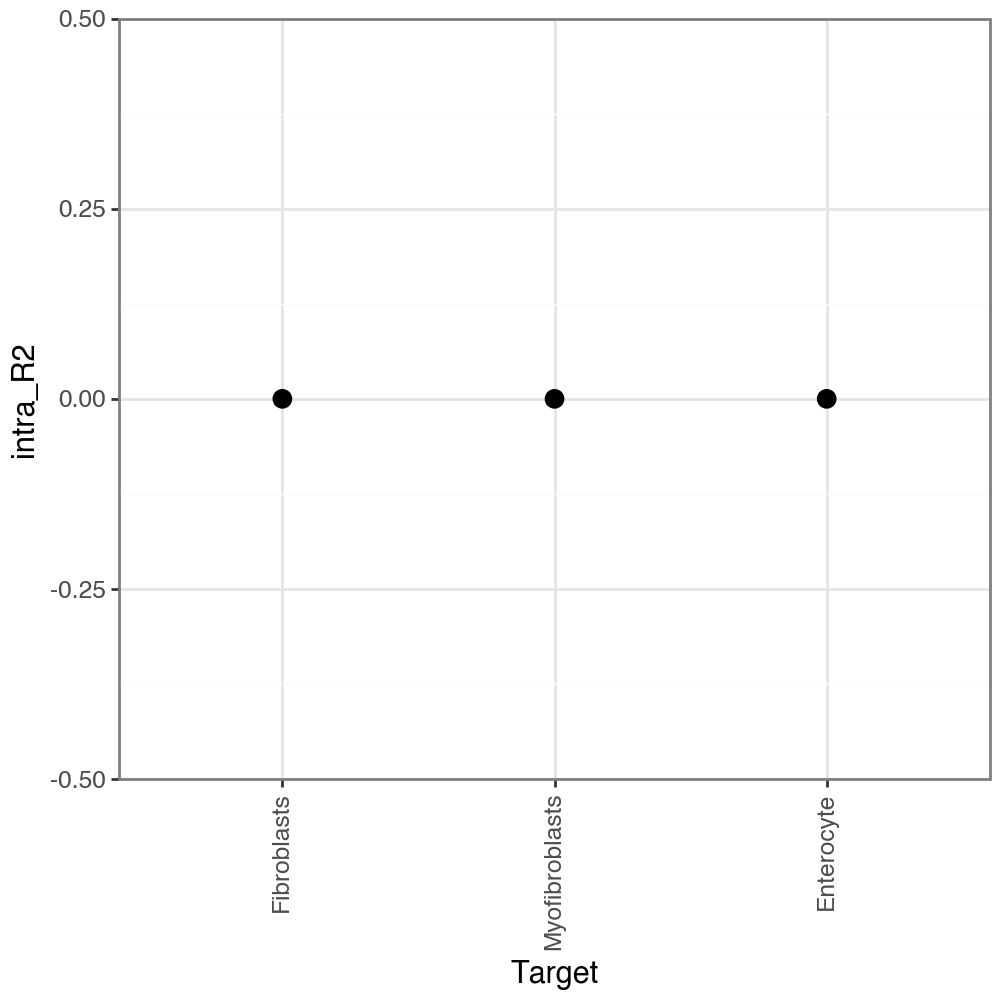

In [25]:
li.pl.target_metrics(misty, stat='intra_R2', return_fig=True)

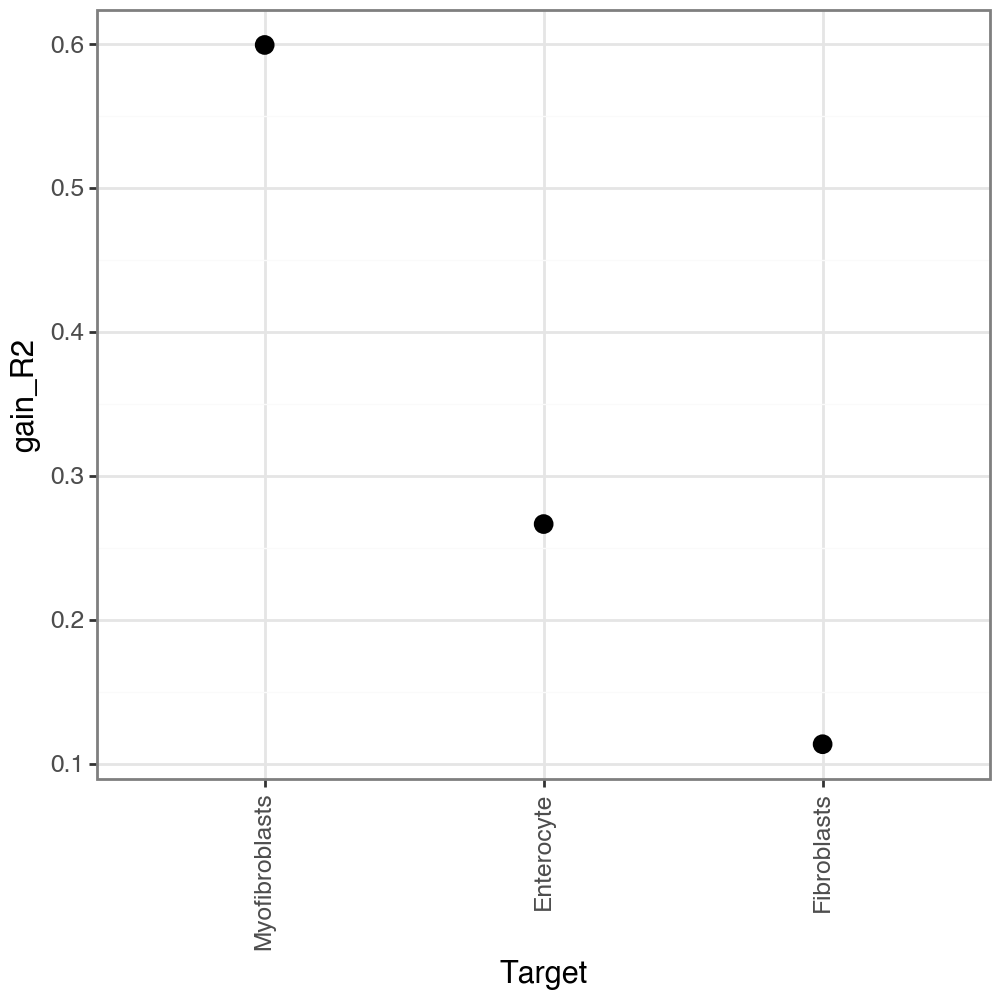

In [44]:
li.pl.target_metrics(misty, stat='gain_R2')

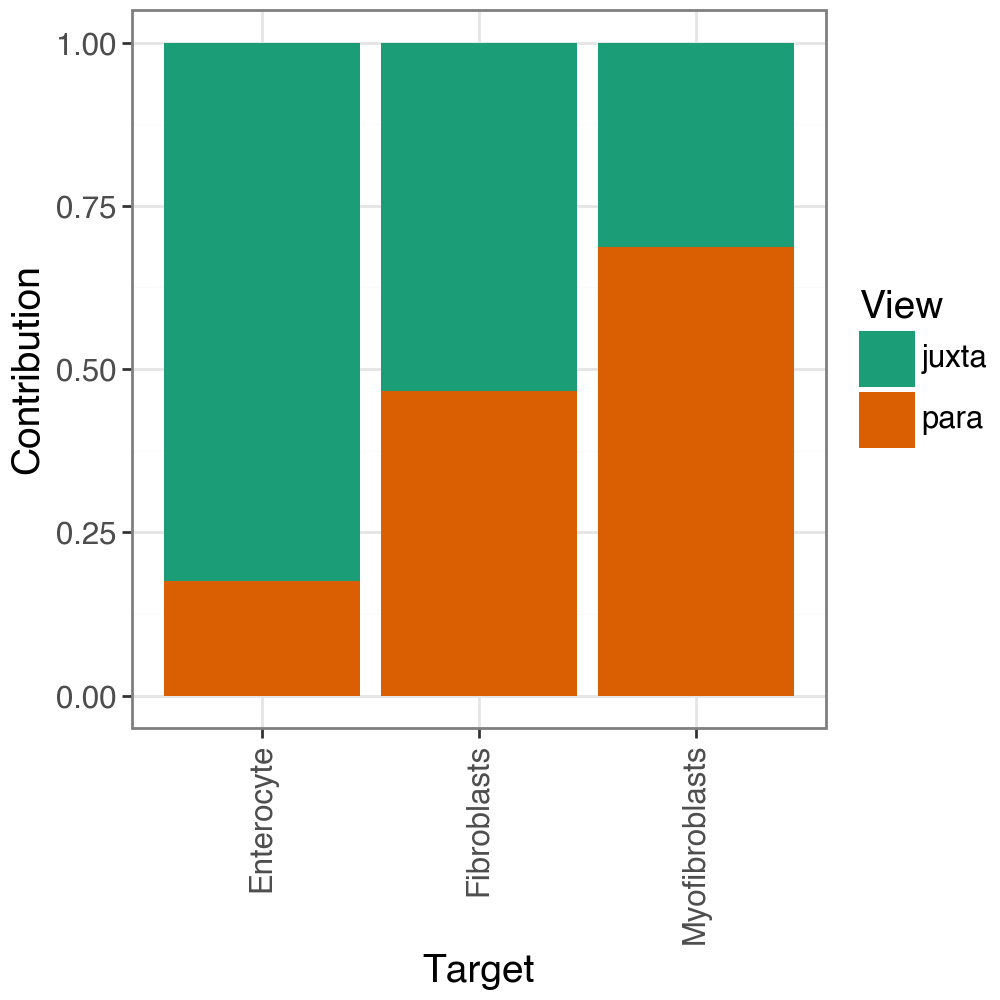

In [45]:
li.pl.contributions(misty, return_fig=True)

In [46]:
misty.uns['interactions'].head()

,target,predictor,view,importances
0,Fibroblasts,Androgen,juxta,60.840557
1,Fibroblasts,EGFR,juxta,7.503645
2,Fibroblasts,Estrogen,juxta,1.078305
3,Fibroblasts,JAK-STAT,juxta,-9.887588
4,Fibroblasts,MAPK,juxta,-1.479514


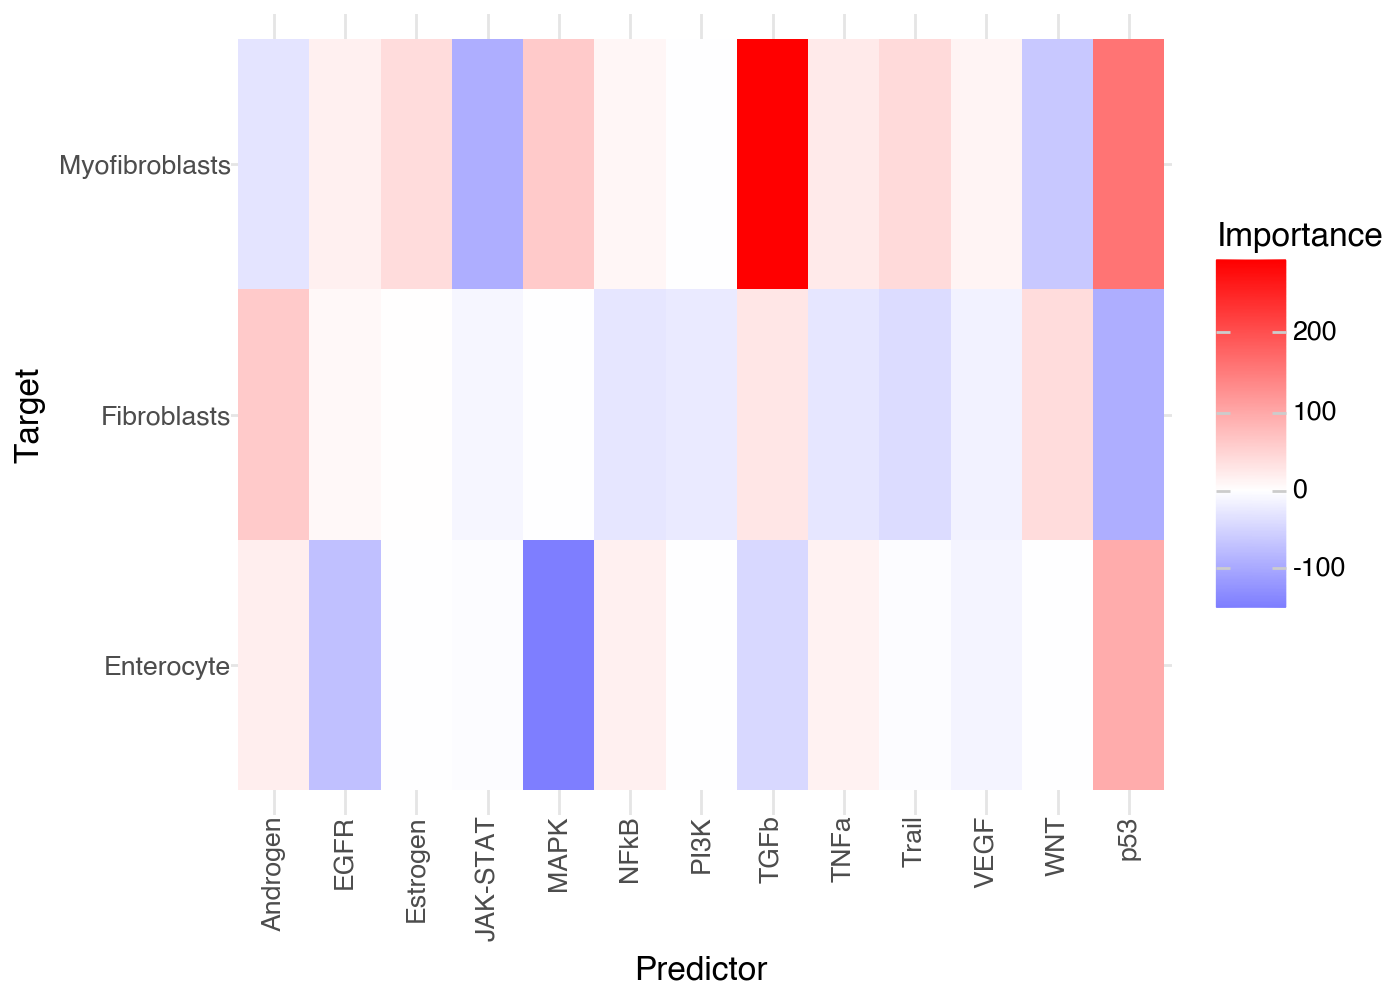

In [47]:
(
    li.pl.interactions(misty, view='juxta', return_fig=True, figure_size=(7,5)) +
    p9.scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0)
)

## Estimate Transcription Factor activities with decoupler

In [26]:
net = dc.get_collectri()

In [27]:
dc.run_ulm(
    mat=adata,
    net=net,
    verbose=True,
    use_raw=False,
)

Running ulm on mat with 274037 samples and 425 targets for 191 sources.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 42.02it/s]


In [28]:
acts_tfs = li.ut.obsm_to_adata(adata, 'ulm_estimate')

In [30]:
acts_tfs.var

""
AHR
AP1
AR
ASCL1
ATF2
...
WT1
YBX1
YY1
ZBTB16


In [31]:
# Calculate spatial neighbors, can be replaced by squidpy function squidpy.gr.spatial_neighbors
li.ut.spatial_neighbors(acts_tfs, cutoff=0.1, bandwidth=200, set_diag=False)

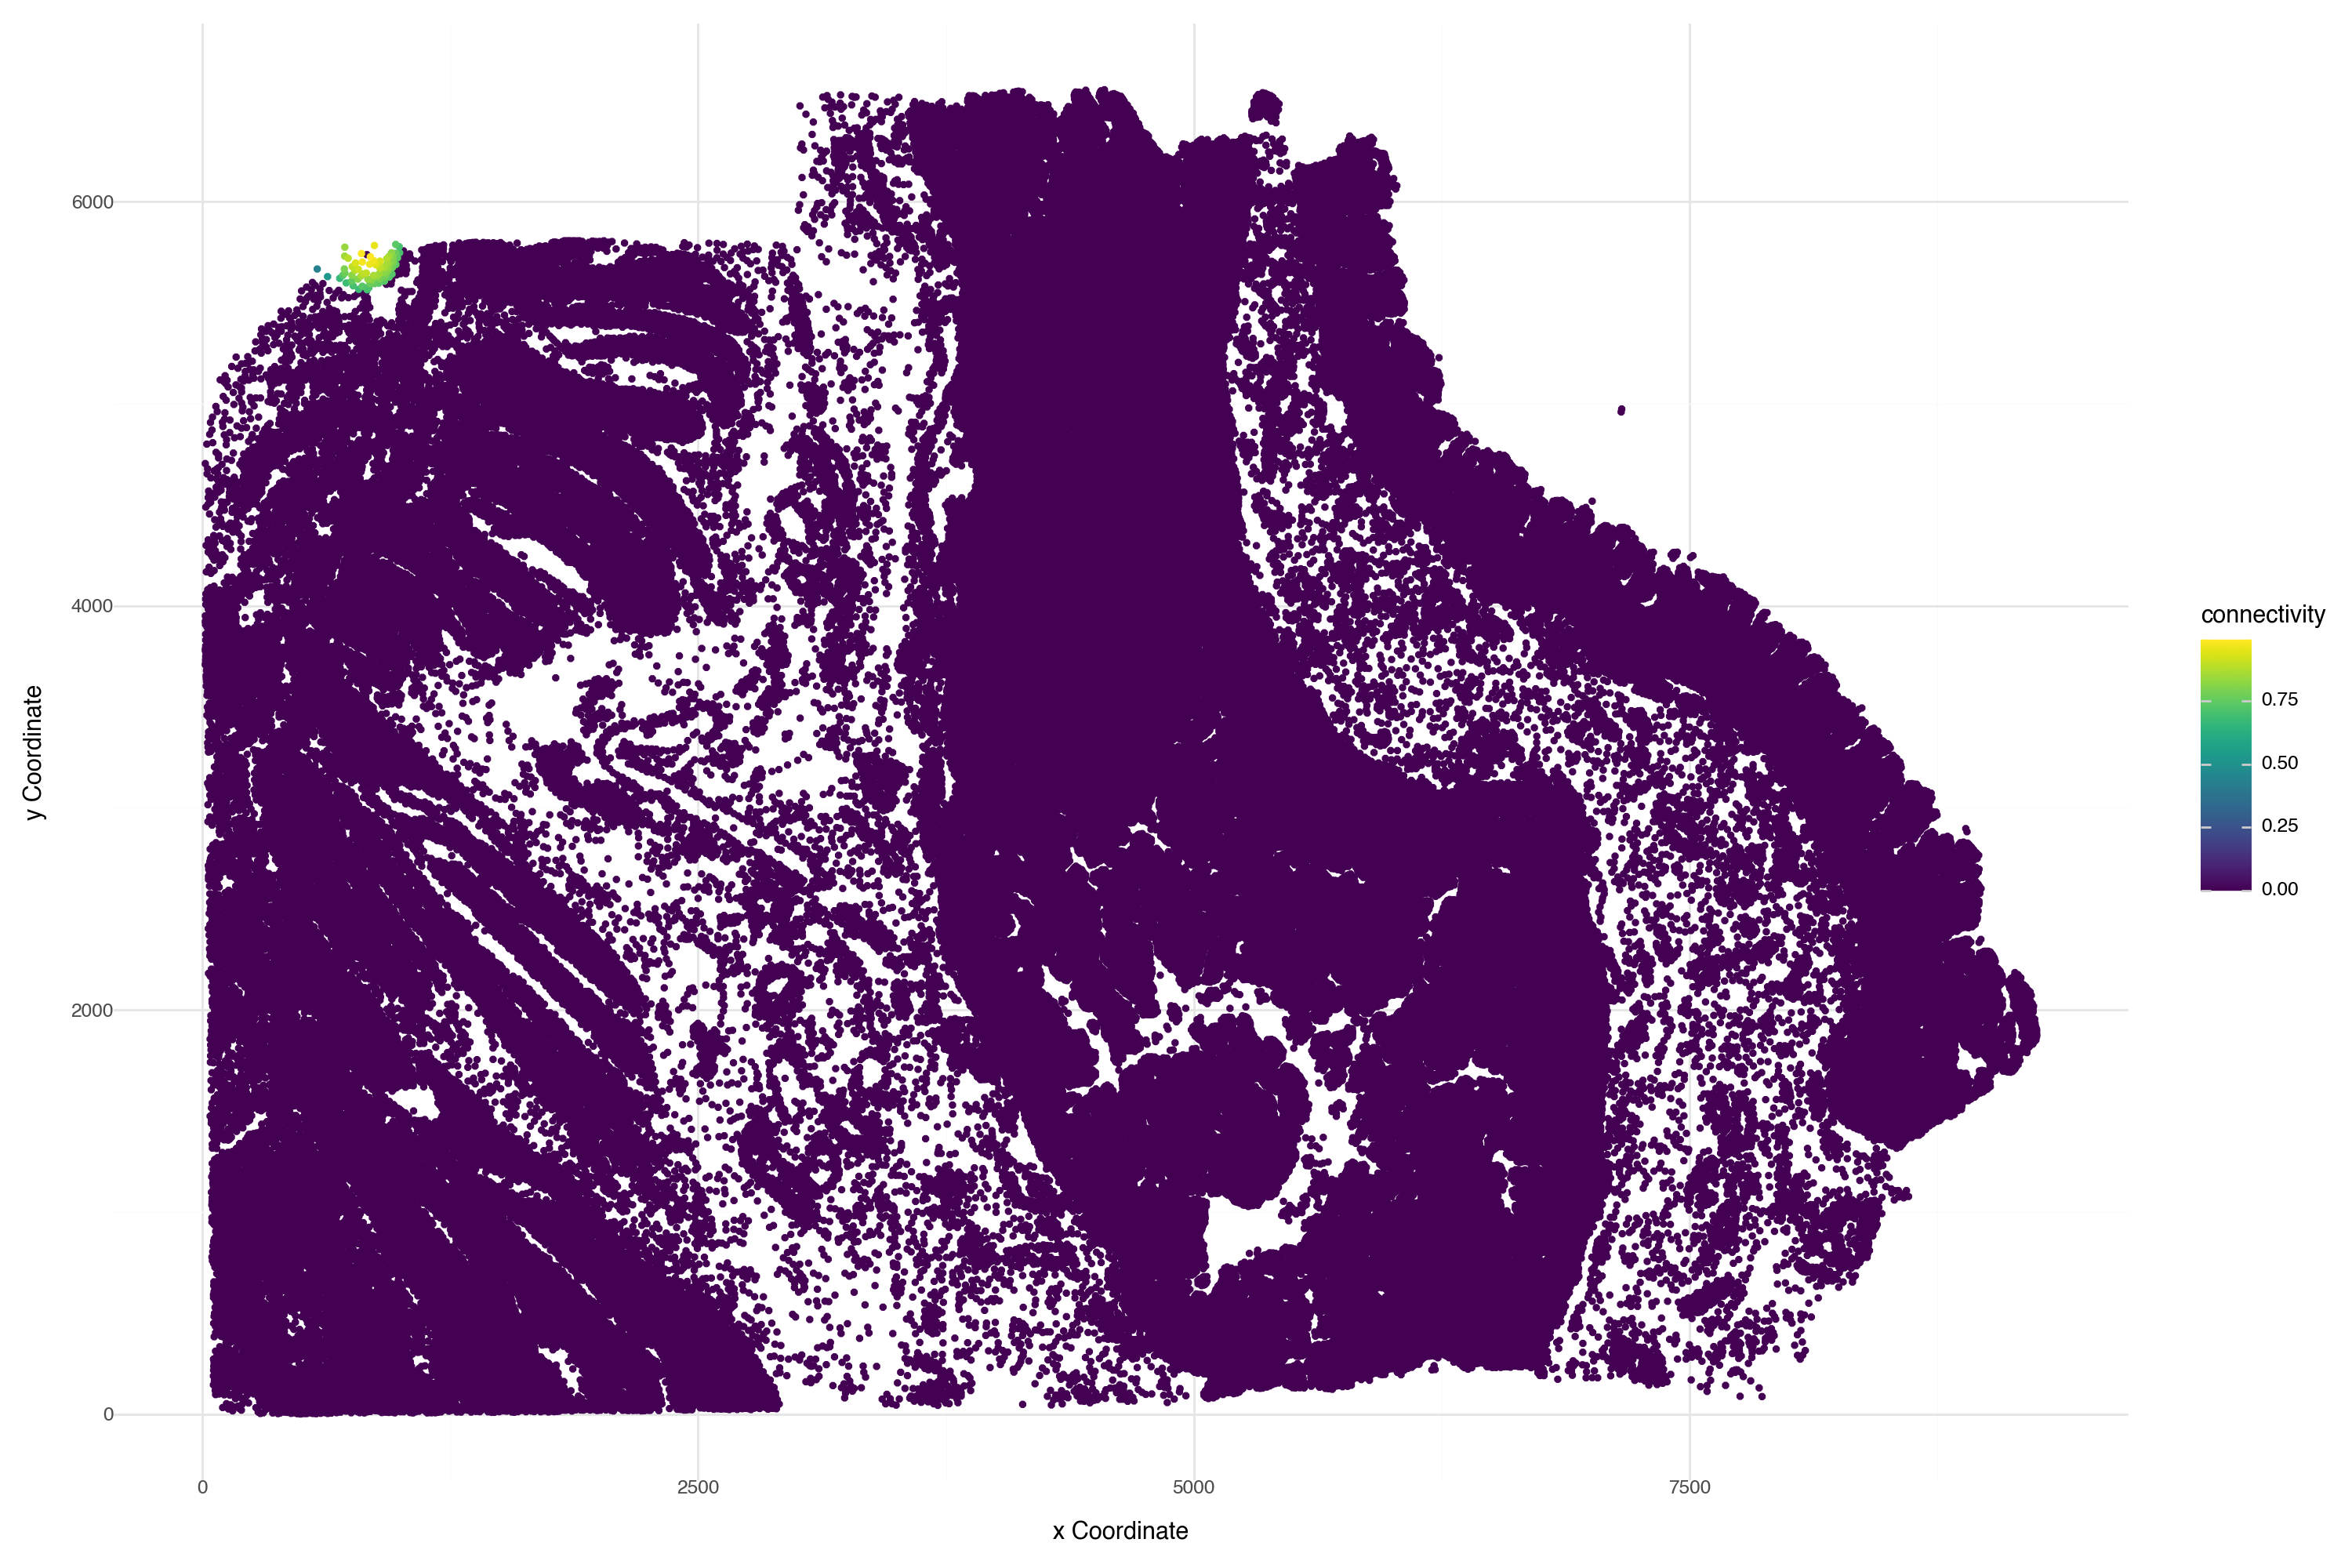

In [55]:
li.pl.connectivity(acts_tfs, idx=0, figure_size=(15,10))

In [32]:
acts_progeny.obsm['spatial'] = acts_tfs.obsm['spatial']
acts_progeny.obsp['spatial_connectivities'] = acts_tfs.obsp['spatial_connectivities']

In [33]:
misty = MistyData(data={"intra": comps, "TFs": acts_tfs, "Pathways": acts_progeny})

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [34]:
misty

MuData object with n_obs × n_vars = 274037 × 238
  obs:	'Study_name', 'Donor_ID', 'Library_Preparation_Protocol', 'dataset', '_scvi_batch', '_scvi_labels', 'seed_labels', 'C_scANVI', 'SC_subsets', 'Cell_State', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'REG4_score', 'gdT', 'Endothelial cells', 'latent_leiden_0.4', 'CD24_ligand_receptor_target_gene_GP', 'SLPI_ligand_receptor_target_gene_GP', 'CXCL14_ligand_receptor_target_gene_GP', 'ANPEP_ligand_receptor_target_gene_GP', 'IL1B_ligand_receptor_target_gene_GP', 'TIMP3_ligand_receptor_target_gene_GP', 'CDH1_ligand_receptor_target_gene_GP', 'TNXB_ligand_receptor_target_gene_GP', 'CLU_ligand_receptor_target_gene_GP', 'TFF1_ligand_receptor_target_gene_GP', 'CCL11_ligand_receptor_target_gene_GP', 'ROBO1_ligand_receptor_target_gene_GP', 'NRG3_ligand_receptor_target_gene_GP', 'gamma-Aminobutyric acid_metabolite_enzyme_sensor_GP', 'Add-on_14_GP', 'THBS1_ligand_receptor_target_gene_GP', 'C1QA_ligand_receptor_target_gene_GP', 'BMP5_ligand_receptor_target_gene_GP', 'Vitamin A_metabolite_enzyme_sensor_GP', 'COL5A2_ligand_receptor_target_gene_GP', 'FCN1_ligand_receptor_target_gene_GP', 'Add-on_74_GP', 'Add-on_22_GP', 'CTSG_ligand_receptor_target_gene_GP', 'APOE_ligand_receptor_target_gene_GP', 'CD6_ligand_receptor_target_gene_GP', 'FCER2_ligand_receptor_target_gene_GP', 'NID1_ligand_receptor_target_gene_GP', 'IGFBP7_ligand_receptor_target_gene_GP', 'COL11A1_ligand_receptor_target_gene_GP', 'CCL20_ligand_receptor_target_gene_GP', 'COL1A1_ligand_receptor_target_gene_GP', 'Add-on_36_GP', 'CEACAM6_ligand_receptor_target_gene_GP', 'CXCL13_ligand_receptor_target_gene_GP', 'AZGP1_ligand_receptor_target_gene_GP', 'Add-on_73_GP', 'COL19A1_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_GP', 'CXCL2_ligand_receptor_target_gene_GP', 'INSL5_ligand_receptor_target_gene_GP', 'GUCA2B_ligand_receptor_target_gene_GP', 'CXCL1_ligand_receptor_target_gene_GP', 'Add-on_13_GP', 'Add-on_11_GP', 'CCL13_ligand_receptor_GP', 'Add-on_35_GP', 'Add-on_24_GP', 'Add-on_7_GP', 'Add-on_55_GP', 'GUCA2A_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_target_gene_GP', 'CCL5_ligand_receptor_target_gene_GP', 'Add-on_44_GP', 'Add-on_4_GP', 'CEACAM1_ligand_receptor_target_gene_GP', 'S100A12_ligand_receptor_target_gene_GP', 'MMP1_ligand_receptor_target_gene_GP', 'PAPLN_ligand_receptor_target_gene_GP', 'TNFSF13B_ligand_receptor_target_gene_GP', 'IFNG_ligand_receptor_target_gene_GP', 'CD79B_ligand_receptor_target_gene_GP', 'VWF_ligand_receptor_target_gene_GP', 'Add-on_56_GP', 'Add-on_78_GP', 'BMP4_ligand_receptor_target_gene_GP', 'TNC_ligand_receptor_target_gene_GP', 'CEACAM5_ligand_receptor_target_gene_GP', 'UCN3_ligand_receptor_target_gene_GP', 'Add-on_49_GP', 'HHLA2_ligand_receptor_target_gene_GP', 'CXCL3_ligand_receptor_target_gene_GP', 'IL32_ligand_receptor_target_gene_GP', 'Add-on_52_GP', 'CCL13_ligand_receptor_target_gene_GP', 'Add-on_50_GP', 'Add-on_26_GP', 'LEFTY1_ligand_receptor_target_gene_GP', 'Add-on_0_GP', 'CEACAM7_ligand_receptor_target_gene_GP', 'Add-on_45_GP', 'RSPO3_ligand_receptor_target_gene_GP', 'Add-on_62_GP', 'Add-on_27_GP', 'SLC6A8_ligand_receptor_target_gene_GP', 'Add-on_53_GP', 'TTR_ligand_receptor_target_gene_GP', 'Add-on_51_GP', 'Add-on_92_GP', 'XCL2_ligand_receptor_target_gene_GP', 'WNT5B_ligand_receptor_target_gene_GP', 'Add-on_39_GP', 'AREG_ligand_receptor_target_gene_GP', 'NRXN1_ligand_receptor_target_gene_GP', 'Add-on_1_GP', 'Add-on_12_GP', 'CD177_ligand_receptor_GP', 'NRG1_ligand_receptor_target_gene_GP', 'GREM1_ligand_receptor_target_gene_GP', 'Add-on_98_GP', 'INHBA_ligand_receptor_target_gene_GP', 'Add-on_88_GP', 'Add-on_10_GP', 'Add-on_79_GP', 'Add-on_9_GP', 'CCL4_ligand_receptor_target_gene_GP', 'Add-on_43_GP', 'SELL_ligand_receptor_target_gene_GP', 'Add-on_41_GP', 'HDC_ligand_receptor_target_gene_

In [35]:
misty(model=LinearModel, verbose=True, bypass_intra=True)

Now learning: Adult Glia: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [07:36<00:00, 13.41s/it]


In [37]:
misty

MuData object with n_obs × n_vars = 274037 × 238
  obs:	'Study_name', 'Donor_ID', 'Library_Preparation_Protocol', 'dataset', '_scvi_batch', '_scvi_labels', 'seed_labels', 'C_scANVI', 'SC_subsets', 'Cell_State', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'REG4_score', 'gdT', 'Endothelial cells', 'latent_leiden_0.4', 'CD24_ligand_receptor_target_gene_GP', 'SLPI_ligand_receptor_target_gene_GP', 'CXCL14_ligand_receptor_target_gene_GP', 'ANPEP_ligand_receptor_target_gene_GP', 'IL1B_ligand_receptor_target_gene_GP', 'TIMP3_ligand_receptor_target_gene_GP', 'CDH1_ligand_receptor_target_gene_GP', 'TNXB_ligand_receptor_target_gene_GP', 'CLU_ligand_receptor_target_gene_GP', 'TFF1_ligand_receptor_target_gene_GP', 'CCL11_ligand_receptor_target_gene_GP', 'ROBO1_ligand_receptor_target_gene_GP', 'NRG3_ligand_receptor_target_gene_GP', 'gamma-Aminobutyric acid_metabolite_enzyme_sensor_GP', 'Add-on_14_GP', 'THBS1_ligand_receptor_target_gene_GP', 'C1QA_ligand_receptor_target_gene_GP', 'BMP5_ligand_receptor_target_gene_GP', 'Vitamin A_metabolite_enzyme_sensor_GP', 'COL5A2_ligand_receptor_target_gene_GP', 'FCN1_ligand_receptor_target_gene_GP', 'Add-on_74_GP', 'Add-on_22_GP', 'CTSG_ligand_receptor_target_gene_GP', 'APOE_ligand_receptor_target_gene_GP', 'CD6_ligand_receptor_target_gene_GP', 'FCER2_ligand_receptor_target_gene_GP', 'NID1_ligand_receptor_target_gene_GP', 'IGFBP7_ligand_receptor_target_gene_GP', 'COL11A1_ligand_receptor_target_gene_GP', 'CCL20_ligand_receptor_target_gene_GP', 'COL1A1_ligand_receptor_target_gene_GP', 'Add-on_36_GP', 'CEACAM6_ligand_receptor_target_gene_GP', 'CXCL13_ligand_receptor_target_gene_GP', 'AZGP1_ligand_receptor_target_gene_GP', 'Add-on_73_GP', 'COL19A1_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_GP', 'CXCL2_ligand_receptor_target_gene_GP', 'INSL5_ligand_receptor_target_gene_GP', 'GUCA2B_ligand_receptor_target_gene_GP', 'CXCL1_ligand_receptor_target_gene_GP', 'Add-on_13_GP', 'Add-on_11_GP', 'CCL13_ligand_receptor_GP', 'Add-on_35_GP', 'Add-on_24_GP', 'Add-on_7_GP', 'Add-on_55_GP', 'GUCA2A_ligand_receptor_target_gene_GP', 'CXCL10_ligand_receptor_target_gene_GP', 'CCL5_ligand_receptor_target_gene_GP', 'Add-on_44_GP', 'Add-on_4_GP', 'CEACAM1_ligand_receptor_target_gene_GP', 'S100A12_ligand_receptor_target_gene_GP', 'MMP1_ligand_receptor_target_gene_GP', 'PAPLN_ligand_receptor_target_gene_GP', 'TNFSF13B_ligand_receptor_target_gene_GP', 'IFNG_ligand_receptor_target_gene_GP', 'CD79B_ligand_receptor_target_gene_GP', 'VWF_ligand_receptor_target_gene_GP', 'Add-on_56_GP', 'Add-on_78_GP', 'BMP4_ligand_receptor_target_gene_GP', 'TNC_ligand_receptor_target_gene_GP', 'CEACAM5_ligand_receptor_target_gene_GP', 'UCN3_ligand_receptor_target_gene_GP', 'Add-on_49_GP', 'HHLA2_ligand_receptor_target_gene_GP', 'CXCL3_ligand_receptor_target_gene_GP', 'IL32_ligand_receptor_target_gene_GP', 'Add-on_52_GP', 'CCL13_ligand_receptor_target_gene_GP', 'Add-on_50_GP', 'Add-on_26_GP', 'LEFTY1_ligand_receptor_target_gene_GP', 'Add-on_0_GP', 'CEACAM7_ligand_receptor_target_gene_GP', 'Add-on_45_GP', 'RSPO3_ligand_receptor_target_gene_GP', 'Add-on_62_GP', 'Add-on_27_GP', 'SLC6A8_ligand_receptor_target_gene_GP', 'Add-on_53_GP', 'TTR_ligand_receptor_target_gene_GP', 'Add-on_51_GP', 'Add-on_92_GP', 'XCL2_ligand_receptor_target_gene_GP', 'WNT5B_ligand_receptor_target_gene_GP', 'Add-on_39_GP', 'AREG_ligand_receptor_target_gene_GP', 'NRXN1_ligand_receptor_target_gene_GP', 'Add-on_1_GP', 'Add-on_12_GP', 'CD177_ligand_receptor_GP', 'NRG1_ligand_receptor_target_gene_GP', 'GREM1_ligand_receptor_target_gene_GP', 'Add-on_98_GP', 'INHBA_ligand_receptor_target_gene_GP', 'Add-on_88_GP', 'Add-on_10_GP', 'Add-on_79_GP', 'Add-on_9_GP', 'CCL4_ligand_receptor_target_gene_GP', 'Add-on_43_GP', 'SELL_ligand_receptor_target_gene_GP', 'Add-on_41_GP', 'HDC_ligand_receptor_target_gene_

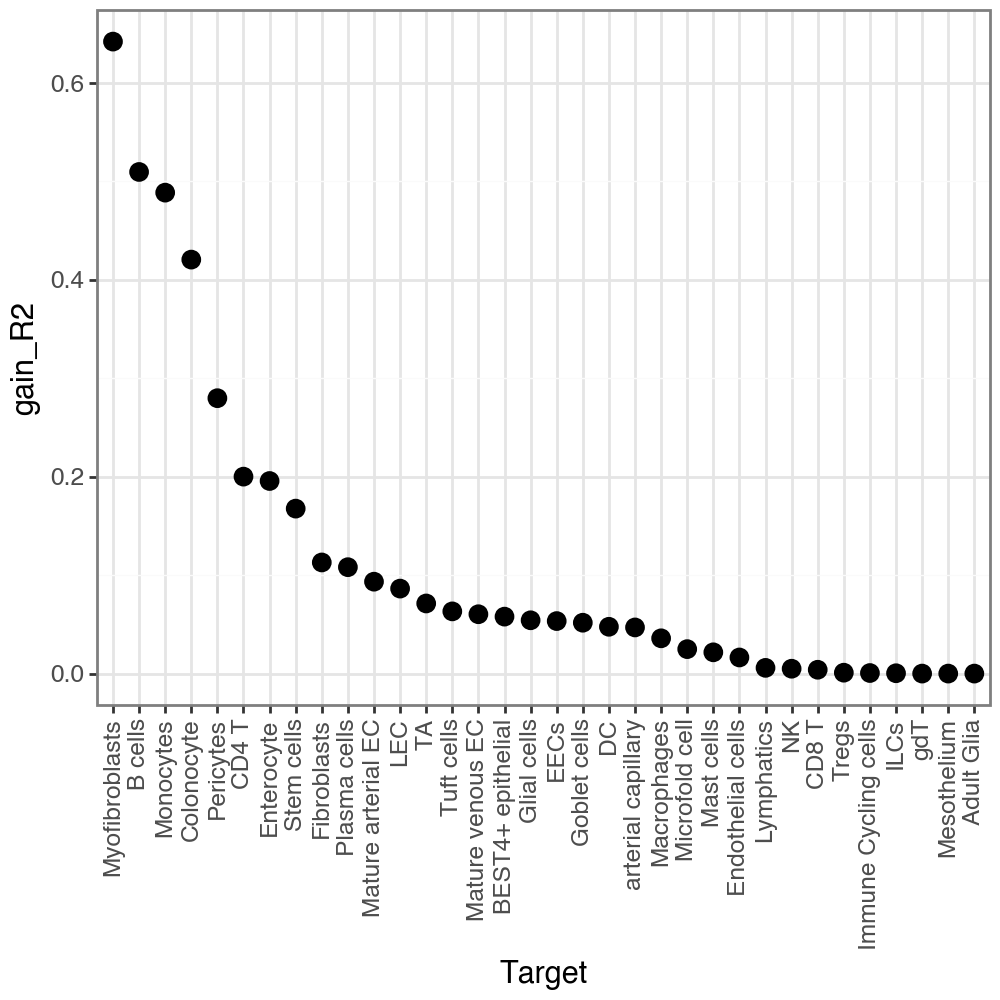

In [36]:
li.pl.target_metrics(misty, stat='gain_R2')

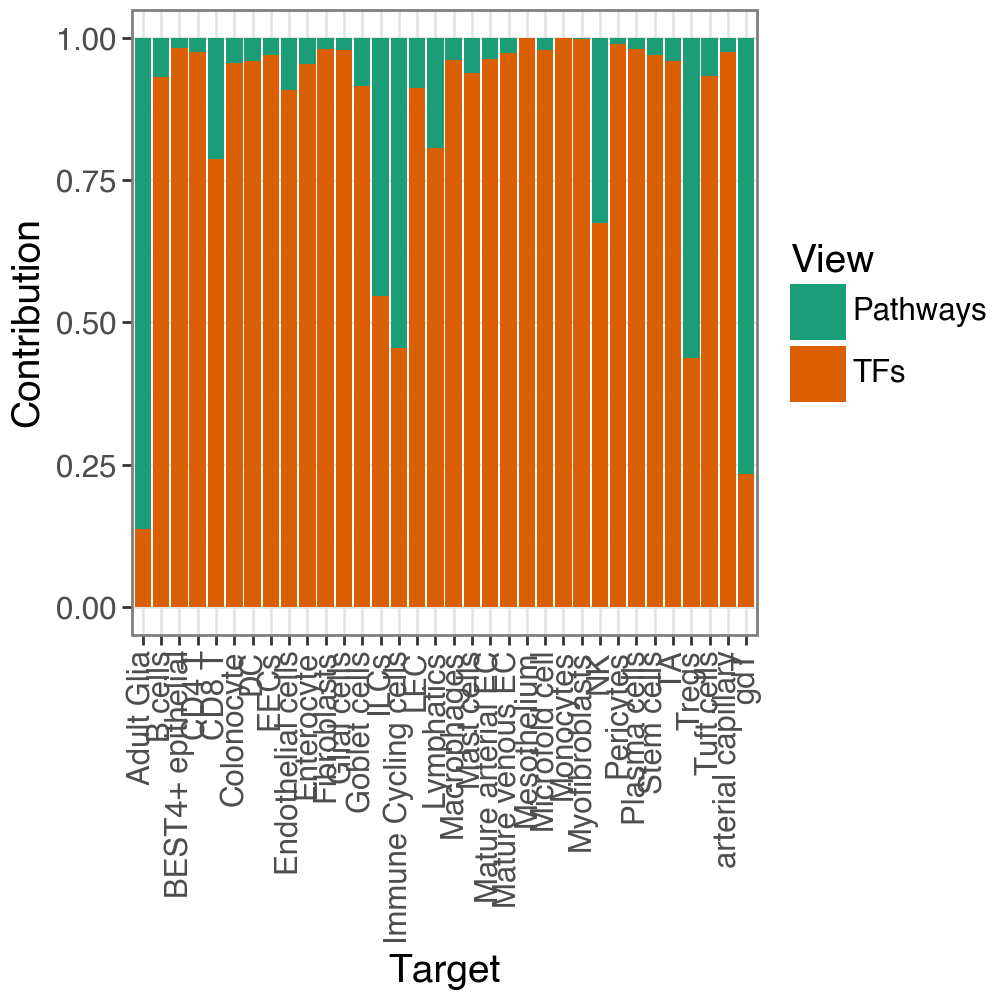

In [62]:
li.pl.contributions(misty, return_fig=True)

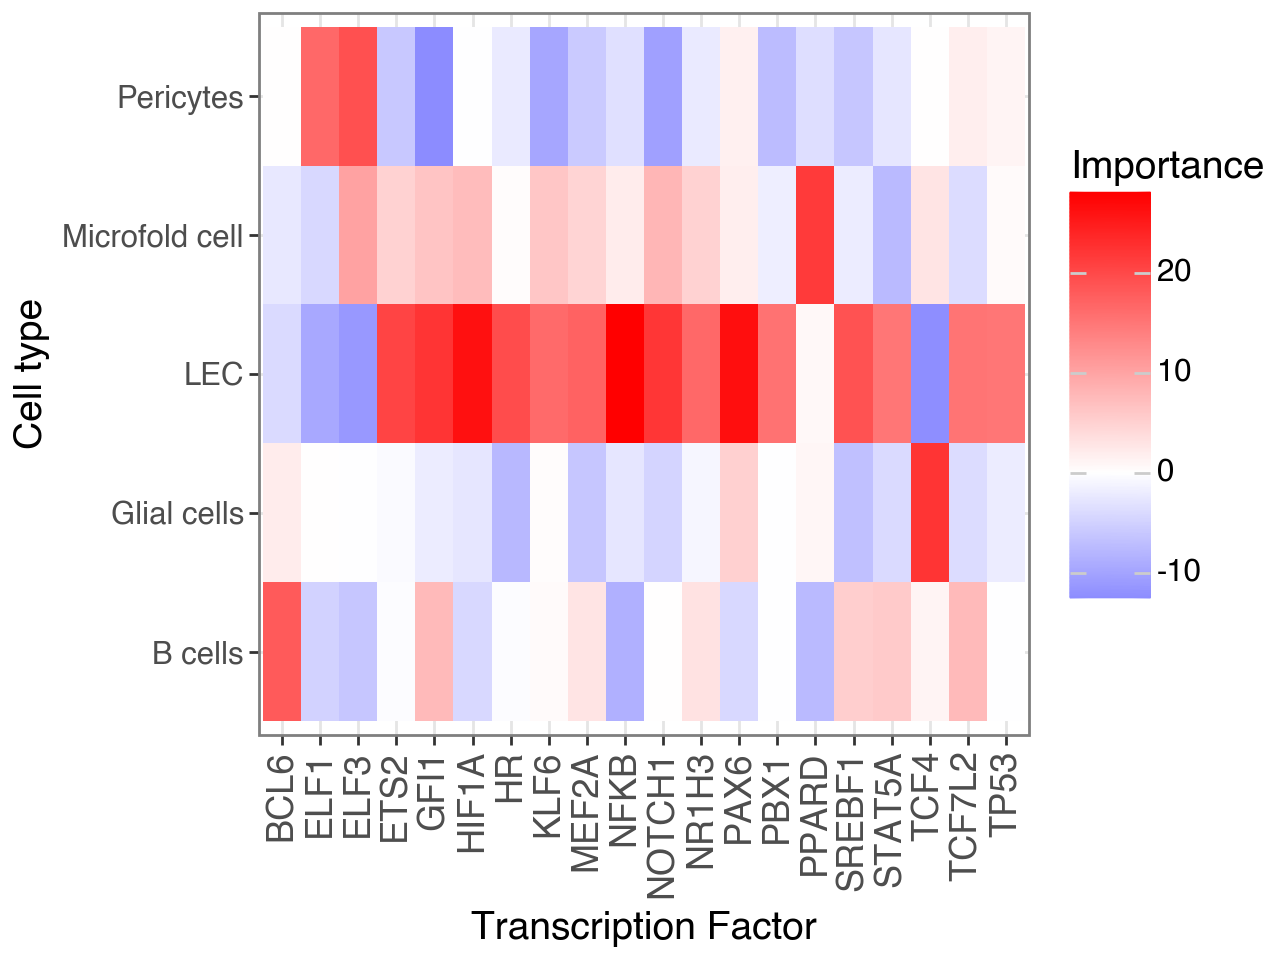

In [63]:
(
    li.pl.interactions(misty, view='TFs', top_n=20) +
    p9.labs(x='Transcription Factor', y='Cell type') +
    p9.theme_bw(base_size=14) +
    p9.theme(axis_text_x=p9.element_text(rotation=90, size=13)) +
    # change to blue-red
    p9.scale_fill_gradient2(low='blue', mid='white', high='red')
)


## Ligand-Receptor Misty

In [ ]:
# If you have many genes, extract HVGs and run the analysis on them, I dont do it because its only 400 genes
sc.pp.highly_variable_genes(adata)
hvg = adata.var[adata.var['highly_variable']].index
misty = lrMistyData(adata[:, hvg], bandwidth=200, set_diag=False, cutoff=0.01, nz_threshold=0.1)

In [64]:
misty = lrMistyData(adata, bandwidth=200, set_diag=False, cutoff=0.01, nz_threshold=0.1)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns fro

In [65]:
misty(bypass_intra=True, model=LinearModel, verbose=True)

Now learning: RNF43: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:16<00:00,  1.53it/s]


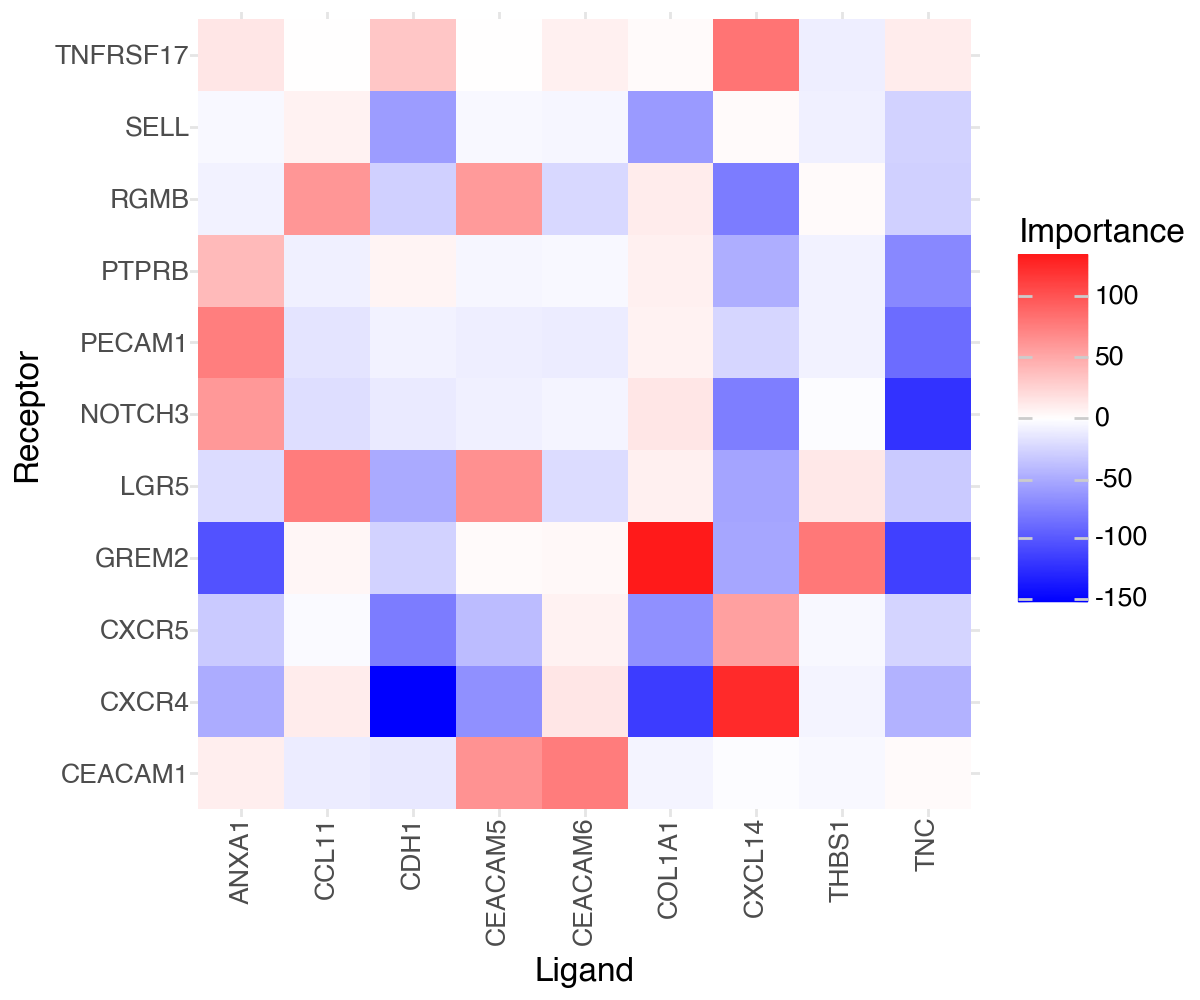

In [66]:
(
    li.pl.interactions(misty, view='extra', return_fig=True, figure_size=(6, 5), top_n=25, key=abs) +
    p9.scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
    p9.labs(y='Receptor', x='Ligand')
)